# Forecast-Validation for ARCH/GARCH Model Selection

Empirical example: 60 GARCH-type models (GARCH, AVGARCH, GJR-GARCH, TARCH, EGARCH, APARCH; Gaussian / Student's t / Skew Student's t) are estimated on a rolling window of daily S&P 500 returns and compared via out-of-sample forecast losses, the StepM and Model Confidence Set multiple-comparison procedures, and a set of *ex-post* diagnostic tests.

See the companion paper under `docs/` and the project `README.md` for the full methodology and API documentation.

In [1]:
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import perf_counter
from datetime import timedelta

plt.rc('figure', figsize=(16,6))
plt.rc('savefig', dpi=90)
sns.set_style('darkgrid')

## Load Data
Daily S&P 500 returns from Yahoo Finance (local-data alternatives are left commented out for reference).

In [2]:
import yfinance as yf
#symbol = 'GBPUSD=X'
symbol = '^GSPC'
start_date = '2016-03-01'
end_date = '2026-03-01'
spx = yf.Ticker(symbol).history(start=start_date, end=end_date)
rs = np.log(spx.Close).diff().dropna() * 100

#ps = pd.read_csv('./data/cisco.csv', index_col=0)
#rs = np.log(ps['CISCO SYSTEMS'].loc[start_date:end_date]).diff().dropna() * 100

#ps = pd.read_csv('./data/DEXUSUK.csv', index_col=0)
#rs = np.log(ps['DEXUSUK'].loc[start_date:end_date]).diff().dropna() * 100

## Drop all rows where returns are zero
rs = rs[rs != 0]

## Set index data type to datetime
rs.index = pd.to_datetime(rs.index)

## Define Candidate Models
Import the desired mean model, volatility processes, and distributions from `arch`, and define every volatility process to be considered.

In [3]:
from arch.univariate import ZeroMean
from arch.univariate import GARCH, EGARCH, APARCH
from arch.univariate.distribution import Normal, StudentsT, SkewStudent

#### Define volatility processes
vol_GARCH_1 = GARCH(1,0,1)
vol_GARCH_2 = GARCH(2,0,2)
vol_AVGARCH_1 = GARCH(1,0,1,power=1)
vol_AVGARCH_2 = GARCH(2,0,2,power=1)

vol_GJR_1 = GARCH(1,1,1)
vol_GJR_2 = GARCH(2,1,2)
vol_GJR_3 = GARCH(2,2,2)
vol_TARCH_1 = GARCH(1,1,1,power=1)
vol_TARCH_2 = GARCH(2,1,2,power=1)
vol_TARCH_3 = GARCH(2,2,2,power=1)

vol_EGARCH_1 = EGARCH(1,0,1)
vol_EGARCH_2 = EGARCH(2,0,2)
vol_EGARCH_3 = EGARCH(1,1,1)
vol_EGARCH_4 = EGARCH(2,1,2)
vol_EGARCH_5 = EGARCH(2,2,2)

vol_APARCH_1 = APARCH(1,0,1)
vol_APARCH_2 = APARCH(2,0,2)
vol_APARCH_3 = APARCH(1,1,1)
vol_APARCH_4 = APARCH(2,1,2)
vol_APARCH_5 = APARCH(2,2,2)

# Custom volatility processes are supported as well, via arch's VolatilityProcess
# abstract class: from arch.univariate.volatility import VolatilityProcess

## collect processes in a single list
vol_processes = [vol_GARCH_1, vol_GARCH_2, vol_AVGARCH_1, vol_AVGARCH_2,
                 vol_GJR_1, vol_GJR_2, vol_GJR_3, vol_TARCH_1, vol_TARCH_2, vol_TARCH_3,
                 vol_EGARCH_1, vol_EGARCH_2, vol_EGARCH_3, vol_EGARCH_4, vol_EGARCH_5,
                 vol_APARCH_1, vol_APARCH_2, vol_APARCH_3, vol_APARCH_4, vol_APARCH_5]

#### Initiate distribution classes
dist_normal = Normal(seed=1776)
dist_studst = StudentsT(seed=1776)
dist_skewt = SkewStudent(seed=1776)

dists = [dist_normal, dist_studst, dist_skewt]

Construct all 60 models from every unique combination of volatility process and distribution.

In [4]:
from itertools import product

proc_combs = list(product(dists, vol_processes))

#### Create all model instances
models = []
for _dist, _vol in proc_combs:
    _mod = ZeroMean(y=rs, volatility=_vol, distribution=_dist)
    models.append(_mod)

models = np.asarray(models, dtype=object)

## Rolling-Window Forecast Validation
Initiate forecast-validation of the model instances via the `Validator` class.

In [5]:
from src.models.validator import Validator

model_validator = Validator(endog=rs, models=models)

## Set the parameters to feed to the validate method
ws = 2016               ## Train on the first 8 years of data
fh = 1                  ## Produce 1-step ahead out of sample forecasts
uf = 21                 ## Update the models every 21 days
alpha = [0.01, 0.05]    ## Significance level for VaR and Expected Shortfall forecasts
align = 'target'        ## Align out-of-sample forecast indices to target date

validate_start = perf_counter()
model_validator.validate(window_size=ws, horizon=fh, update_frequency=uf,
                         alpha=alpha, align=align)
validate_elapsed = perf_counter() - validate_start
print(f'Time elapsed: {timedelta(seconds=validate_elapsed)}')

/home/tl/Documents/Repos/sfclubunibo-arch-fv/src/models/validator.py:269: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  _fit = md.fit(first_obs=i, last_obs=window_size + i,
/tmp/ipykernel_730893/3994933790.py:13: UserWarning: Warm-started fit did not converge for model 59 (APARCH) at window ending index 2330; refitting from default starting values.
  model_validator.validate(window_size=ws, horizon=fh, update_frequency=uf,
/home/tl/Documents/Repos/sfclubunibo-arch-fv/src/models/validator.py:286: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  _fit = md.fit(first_obs=i, last_obs=window_size + i,


Time elapsed: 0:05:47.234667


In [6]:
## Make deep copies of the parameters
## These deep copies prove to be useful as some models might be eliminated
## before running the StepM and MCS procedures without altering the class attributes.
md_forecasts = model_validator.forecasts.copy(deep=True)
md_residuals = model_validator.std_residuals.copy(deep=True)
md_mse = model_validator.mse_loss.copy(deep=True)
md_qlike = model_validator.qlike_loss.copy(deep=True)
md_var = model_validator.value_at_risk.copy(deep=True)
md_exp = model_validator.expected_shortfall.copy(deep=True)

## Forecasts of horizons greater than 1 are not available for some models,
## hence they will be dropped
md_forecasts.dropna(axis = 1, inplace=True)
md_residuals.dropna(axis = 1, inplace=True)
md_mse.dropna(axis = 1, inplace=True)
md_qlike.dropna(axis = 1, inplace=True)
md_var.dropna(axis = 1, inplace=True)
md_exp.dropna(axis = 1, inplace=True)

### Returns vs. Forecasted Volatility Envelopes

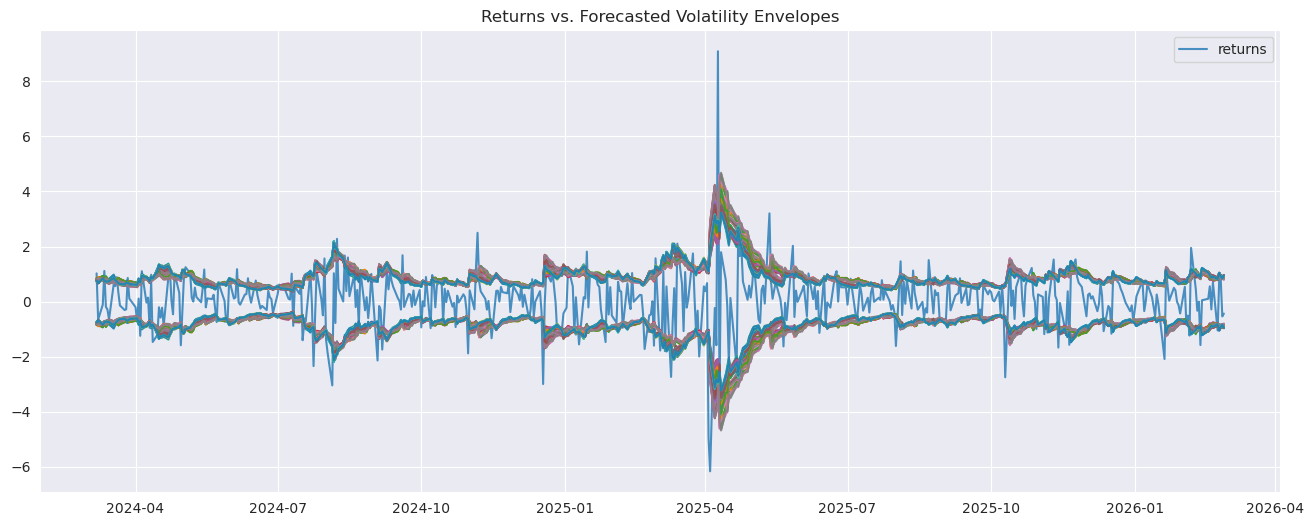

In [7]:
## Align the indices of the test set and the forecasts for data visualization
rs_test = rs.loc[md_forecasts.index]

## Data Visualization : Returns vs. Forecasted Volatility Envelopes
fig, ax = plt.subplots()
ax.plot(rs_test, alpha=0.8, label='returns')
ax.plot(np.sqrt(md_forecasts), alpha=0.8)
ax.plot(-1*np.sqrt(md_forecasts), alpha=0.8)
ax.legend()
ax.set_title('Returns vs. Forecasted Volatility Envelopes')
plt.show()

## StepM and MCS Comparison Procedures
To run multiple comparison procedures, first estimate the optimal bootstrap block size for the target loss series. Multiple comparisons are based on the QLIKE loss series here; any of the other loss functions (MSE, MAE) may be used instead.

In [8]:
from src.modules.bootstrap_params import bootstrap_block_size
opt_bs = bootstrap_block_size(md_qlike).max()
print(opt_bs)
opt_sb = np.ceil(opt_bs['Stationary Bootstrap'])
opt_cb = np.ceil(opt_bs['Circular Bootstrap'])
opt_mb = np.ceil(opt_bs['Moving-Blocks Bootstrap'])

Stationary Bootstrap       13.972426
Circular Bootstrap         15.994435
Moving-Blocks Bootstrap    15.994435
dtype: float64


### StepM
For StepM, the benchmark is always the GARCH(1,1) specification with Gaussian likelihood function.

In [9]:
## First need to find the model index corresponding to the GARCH(1,1) + Gaussian specification
bm = next(
    md for md in models
    if md.volatility == vol_GARCH_1 and md.distribution == dist_normal
    )
bm_indx = np.where(models == bm)[0][0]

bm_losses = md_qlike.loc[:, bm_indx]
alt_losses = md_qlike.loc[:, md_qlike.columns != bm_indx]

from arch.bootstrap import StepM
stepm = StepM(benchmark=bm_losses, models=alt_losses, size=0.05, reps=1000,
              block_size=opt_sb, bootstrap='stationary', seed=1776)
stepm.compute()

### MCS

In [10]:
from arch.bootstrap import MCS
mcs = MCS(losses=md_qlike, size=0.05, reps=1000,
          block_size=opt_sb, bootstrap='stationary', seed = 1776)
mcs.compute()

### Visualizations
#### Loss densities
Group models based on their likelihood functions and ravel the loss arrays (the first 20 models use the Gaussian likelihood function, the second 20 the Student's t, and the final 20 the Skew Student's t).

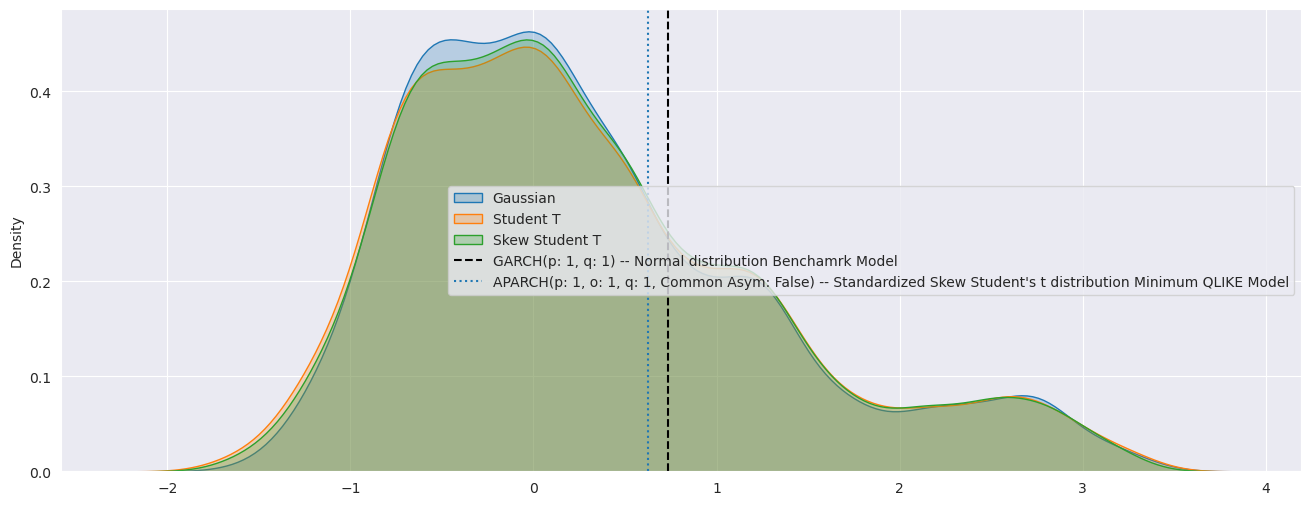

In [11]:
ravel_qlike_gu = md_qlike.iloc[:,:20].to_numpy().ravel()
ravel_qlike_st = md_qlike.iloc[:,20:40].to_numpy().ravel()
ravel_qlike_sk = md_qlike.iloc[:,-20:].to_numpy().ravel()

## Only keep losses up to the 95th quantile, this is convenient for visual inspection
ravel_qlike_gu = ravel_qlike_gu[ravel_qlike_gu < np.quantile(ravel_qlike_gu, 0.95)]
ravel_qlike_st = ravel_qlike_st[ravel_qlike_st < np.quantile(ravel_qlike_st, 0.95)]
ravel_qlike_sk = ravel_qlike_sk[ravel_qlike_sk < np.quantile(ravel_qlike_sk, 0.95)]

## Compute the mean qlike loss for Benchmark and the min qlike model
bm_qlike = md_qlike.loc[:, bm_indx].mean()
min_qlike = md_qlike.mean().min()

## Find the corresponding model with minimum qlike score
min_qlike_indx = md_qlike.mean()[md_qlike.mean() == min_qlike].index[0]
min_qlike_vol = str(models[min_qlike_indx].volatility)
min_qlike_dist = str(models[min_qlike_indx].distribution)
min_qlike_model = min_qlike_vol + ' -- ' + min_qlike_dist

## Do the same for the Benchmark
bm_model = str(models[bm_indx].volatility) + ' -- ' + str(models[bm_indx].distribution)

## Plot KDE plots of model losses
sns.kdeplot(ravel_qlike_gu, label='Gaussian', fill=True)
sns.kdeplot(ravel_qlike_st, label='Student T', fill=True)
sns.kdeplot(ravel_qlike_sk, label='Skew Student T', fill=True)
plt.axvline(bm_qlike, label=bm_model + ' Benchamrk Model', color='black', linestyle='dashed')
plt.axvline(min_qlike, label=min_qlike_model + ' Minimum QLIKE Model', linestyle='dotted')
plt.legend()
plt.show()

Text(0, 0.5, 'QLIKE Score')

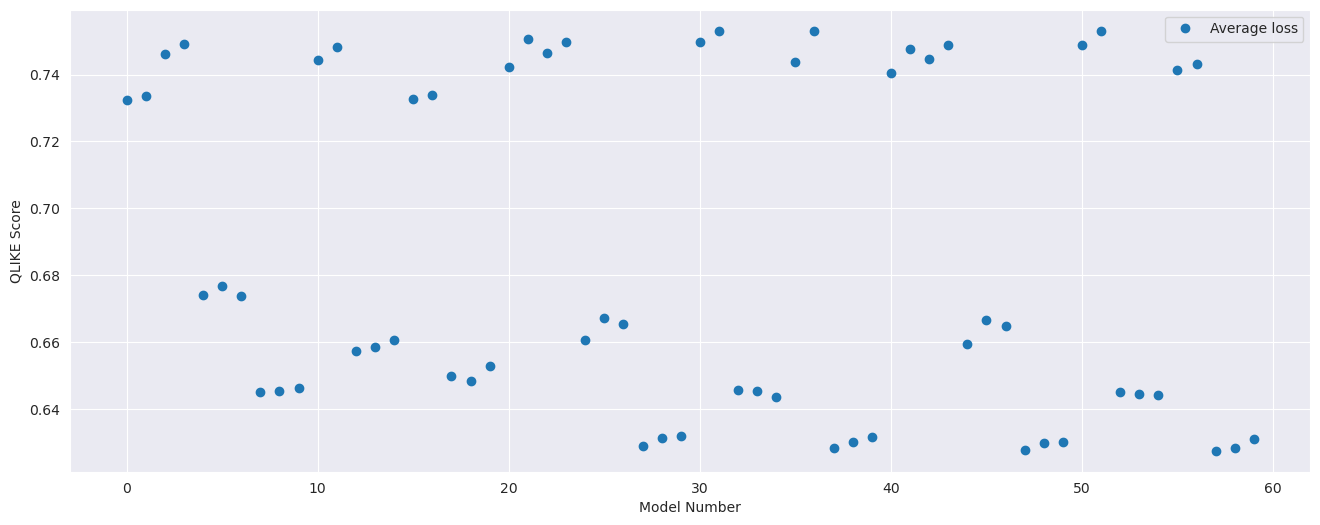

In [12]:
avg_qlike = pd.DataFrame(md_qlike.mean(), columns=["Average loss"])
fig = avg_qlike.plot(style=['o'])
fig.set_xlabel('Model Number')
fig.set_ylabel('QLIKE Score')

Text(0, 0.5, 'QLIKE Score')

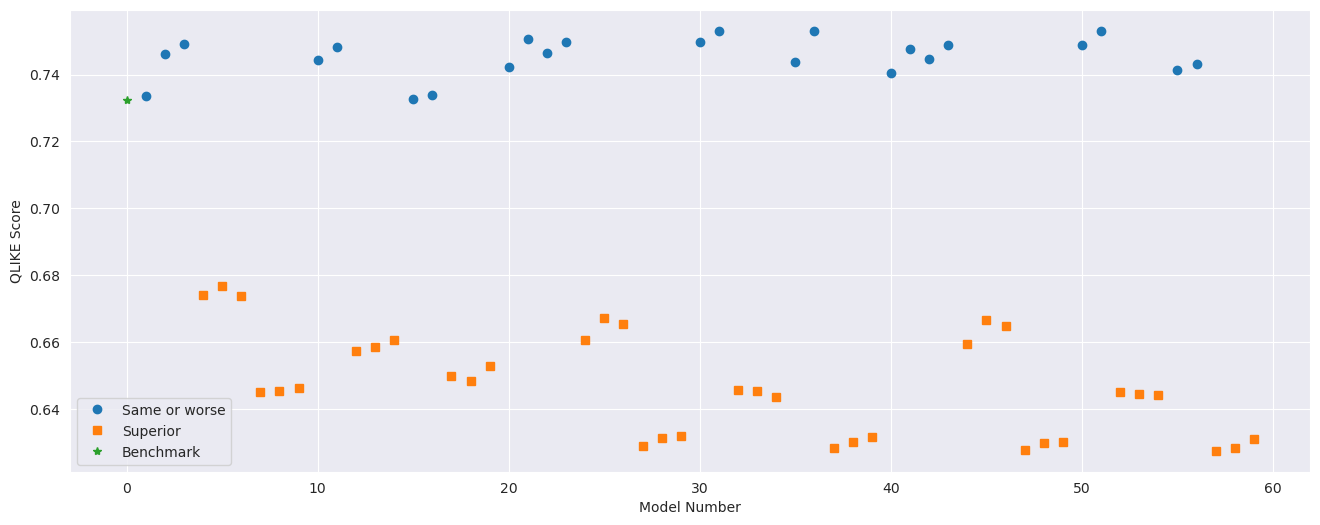

In [13]:
stepm_models = pd.concat([alt_losses.mean(), alt_losses.mean(), alt_losses.mean()], axis=1)
stepm_models.columns = ["Same or worse", "Superior", "Benchmark"]
sup = stepm_models.index.isin(stepm.superior_models)
worse = np.logical_not(sup)
stepm_models.loc[sup, "Same or worse"] = np.nan
stepm_models.loc[worse, "Superior"] = np.nan
stepm_models.loc[:, "Benchmark"] = np.nan
## Add benchmark back to the data frame
stepm_models.loc[bm_indx, "Benchmark"] = bm_losses.mean()
fig = stepm_models.plot(style=["o", "s", "*"])
fig.set_xlabel('Model Number')
fig.set_ylabel('QLIKE Score')

Text(0, 0.5, 'QLIKE Score')

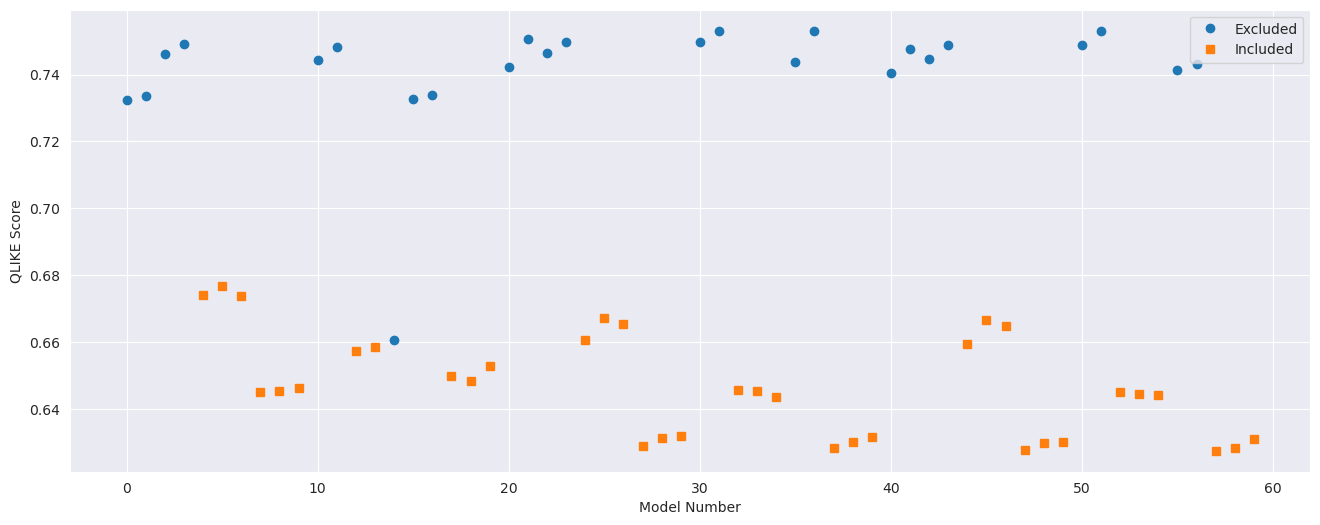

In [14]:
status = pd.DataFrame(
    [md_qlike.mean(0), md_qlike.mean(0)], index=["Excluded", "Included"]
).T
status.loc[status.index.isin(mcs.included), "Excluded"] = np.nan
status.loc[status.index.isin(mcs.excluded), "Included"] = np.nan
fig = status.plot(style=["o", "s"])
fig.set_xlabel('Model Number')
fig.set_ylabel('QLIKE Score')

## Diagnostic Tests
### Moment Conditions via the SupF CUSUM Test

In [15]:
test_size = 0.05        # size of the tests

from src.modules.standard_diagnostics import cusum_supf_test
moments = [2,4]
moment_conditions = np.zeros(shape=(len(models), len(moments)))
for i in range(len(models)):
    for j in range(len(moments)):
        _test = cusum_supf_test(md_residuals[i], moments[j])
        pvalue = _test['P-value']
        if pvalue > test_size:
            moment_conditions[i,j] = 1
        else:
            moment_conditions[i,j] = 0

mcol_str = 'Moment Order_{0:0' + 'd}'
mcols = [mcol_str.format(i) for i in moments]
moment_conditions = pd.DataFrame(moment_conditions, columns=mcols)
print(moment_conditions)

    Moment Order_2  Moment Order_4
0              1.0             1.0
1              1.0             1.0
2              1.0             1.0
3              1.0             1.0
4              1.0             1.0
5              1.0             1.0
6              1.0             1.0
7              1.0             1.0
8              1.0             1.0
9              1.0             1.0
10             1.0             1.0
11             1.0             1.0
12             1.0             1.0
13             1.0             1.0
14             1.0             1.0
15             1.0             1.0
16             1.0             1.0
17             1.0             1.0
18             1.0             1.0
19             1.0             1.0
20             1.0             1.0
21             1.0             1.0
22             1.0             1.0
23             1.0             1.0
24             1.0             1.0
25             1.0             1.0
26             1.0             1.0
27             1.0  

### Pickands' Tail Index Estimator

In [16]:
from src.modules.standard_diagnostics import GenParetoMLE, tail_index_ci
tail_indx = np.zeros(shape=(len(models), 3))
for i in range(len(models)):
    zs = md_residuals[i]
    thresh = np.percentile(zs, 95)
    exs = zs[zs > thresh] - thresh
    gp = GenParetoMLE(exs)
    gp_fit = gp.fit()
    xi_hat = gp_fit.params[0]
    sigma_hat = gp_fit.params[1]

    if xi_hat < -0.5:
        tail_indx[i,0] = np.round(xi_hat, decimals=2)
        tail_indx[i,1] = np.nan
        tail_indx[i,2] = np.nan
        continue

    _ci = tail_index_ci(exs, xi_hat, sigma_hat, alpha=test_size)
    tail_indx[i,0] = _ci['xi_hat']
    tail_indx[i,1] = _ci['CI Lower']
    tail_indx[i,2] = _ci['CI Upper']

tcols = ['Tail Index', 'CI Lower', 'CI Upper']
tail_indx = pd.DataFrame(tail_indx, columns=tcols)
print(tail_indx)

Optimization terminated successfully.
         Current function value: 0.269558
         Iterations: 42
         Function evaluations: 81
Optimization terminated successfully.
         Current function value: 0.283282
         Iterations: 42
         Function evaluations: 78
Optimization terminated successfully.
         Current function value: 0.401366
         Iterations: 41
         Function evaluations: 77
Optimization terminated successfully.
         Current function value: 0.426929
         Iterations: 45
         Function evaluations: 87
Optimization terminated successfully.
         Current function value: 0.107559
         Iterations: 51
         Function evaluations: 99
Optimization terminated successfully.
         Current function value: 0.096820
         Iterations: 44
         Function evaluations: 83
Optimization terminated successfully.
         Current function value: 0.042626
         Iterations: 40
         Function evaluations: 74
Optimization terminated successful

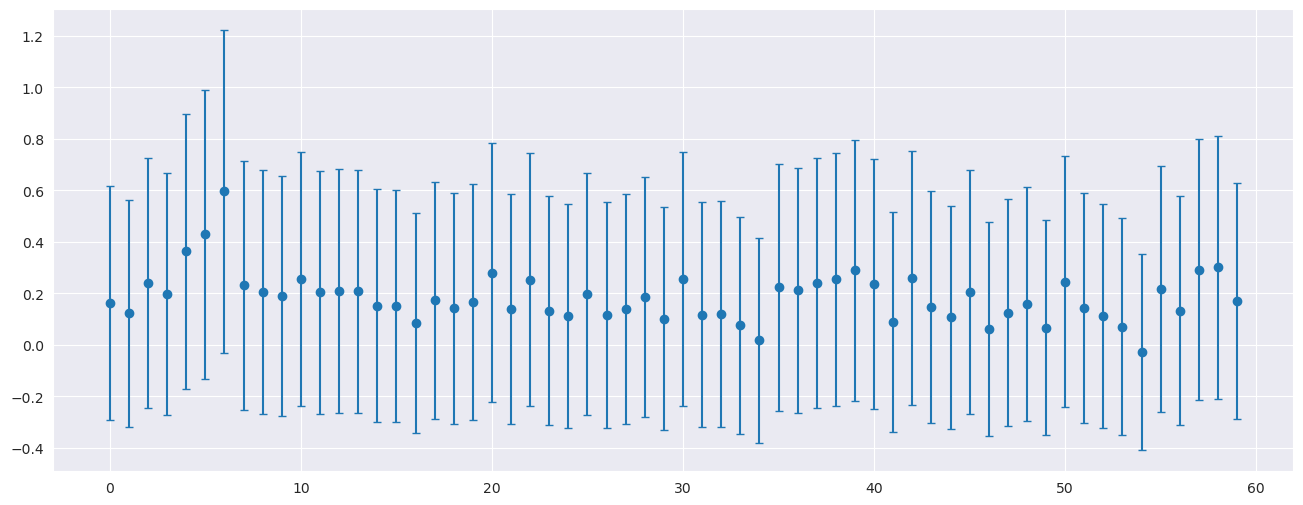

In [17]:
## Visualize the tail index estimates and the corresponding confidence intervals
fig, ax = plt.subplots()
yerr = [tail_indx['Tail Index'] - tail_indx['CI Lower'],
        tail_indx['CI Upper'] - tail_indx['Tail Index']]
ax.errorbar(x=range(len(tail_indx)), y=tail_indx['Tail Index'], yerr=yerr, fmt='o', capsize=3)
plt.show()

### Jarque-Bera Test
This test can only be carried out for specifications with the Normal distribution.

In [18]:
from src.modules.standard_diagnostics import jb_test
md_indx = [i for i, md in enumerate(models) if md.distribution == dist_normal]

jb_norm = np.zeros(shape=(len(md_indx),1))
for i in range(len(md_indx)):
    zs = md_residuals[md_indx[i]]
    _test = jb_test(zs)
    pvalue = _test['P-value']
    if pvalue > test_size:
        jb_norm[i] = 1
    else:
        jb_norm[i] = 0

jbcols = ['JB Test']
jb_norm = pd.DataFrame(jb_norm, index=md_indx, columns=jbcols)
print(jb_norm)

    JB Test
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
5       0.0
6       0.0
7       0.0
8       0.0
9       0.0
10      0.0
11      0.0
12      0.0
13      0.0
14      0.0
15      0.0
16      0.0
17      0.0
18      0.0
19      0.0


## VaR and ES Forecasts
Choose a benchmark model or a set of benchmark models for which to compute the number of exceedances.

In [19]:
superior_var = md_var.loc[:, md_var.columns.get_level_values('Model').isin(stepm.superior_models)]
included_var = md_var.loc[:, md_var.columns.get_level_values('Model').isin(mcs.included)]